In [1]:
import os
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.patches import Rectangle

import numpy as np
import pandas as pd

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [2]:
# Define a scaling factor
scale_factor = 1.5

# Update default font sizes by multiplying with the scaling factor
rcParams['font.size'] *= scale_factor       # Default font size

In [3]:
training_seed = 1
test_seed = 101
env_id = "CARLPendulum"
methods = ["vanilla", "stacked", "oracle", "oracle_stacked", "osi", "dm"]
method_names = {
    "vanilla": "Vanilla",
    "stacked": "Stacked",
    "oracle": "Oracle",
    "oracle_stacked": "Oracle + Stacked",
    "osi": "OSI",
    "dm": "DM"
}
test_env_config_ids = [f"test_{i}" for i in range(1, 101)]
c1_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]
c2_values = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]

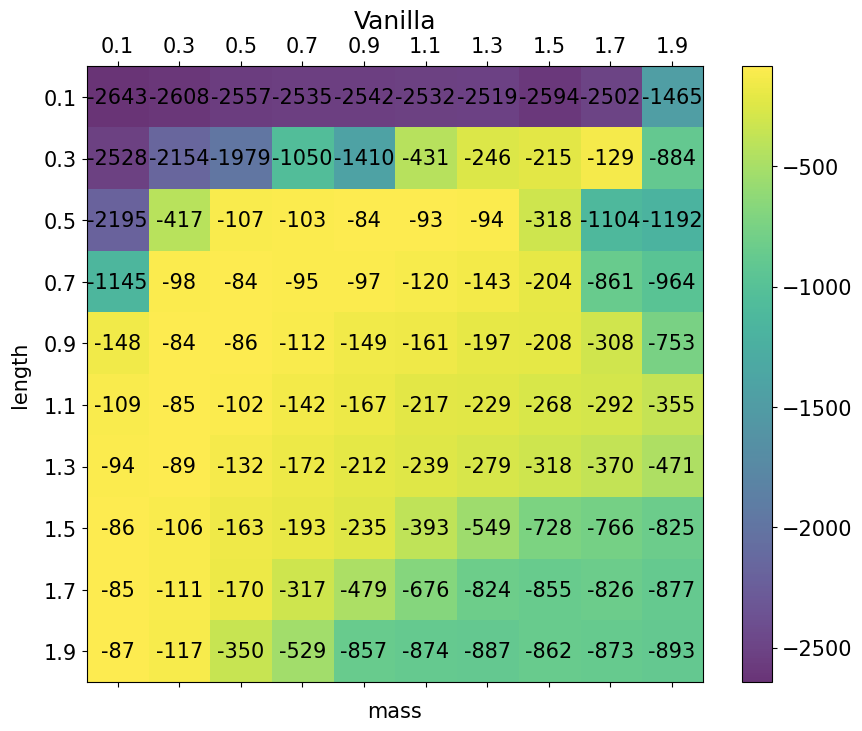

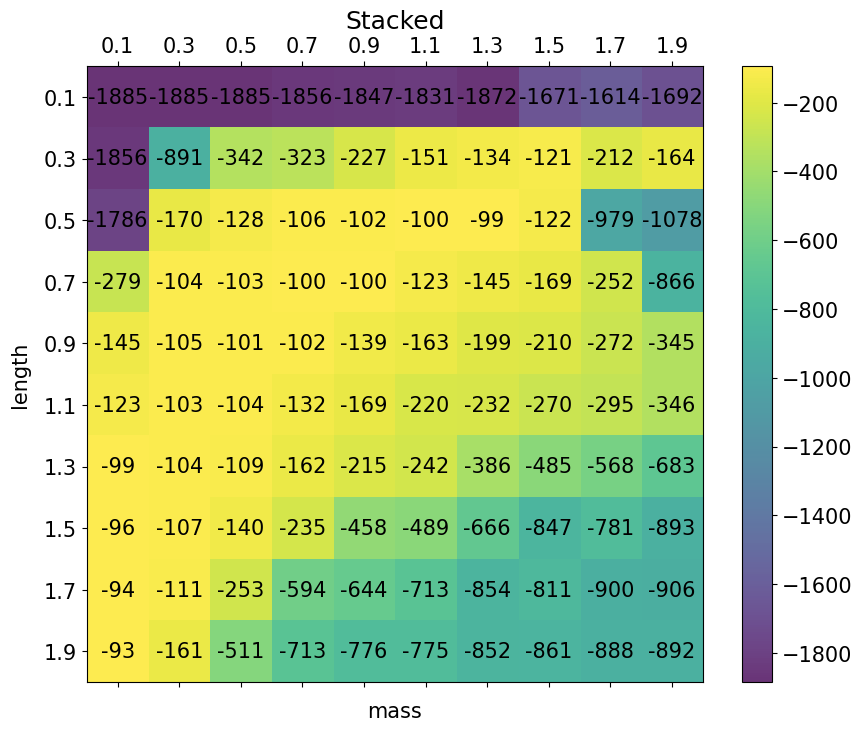

In [4]:
env_config_id = "default"

# checkpoint_idxs = defaultdict(list)
return_means = defaultdict(list)
return_stds = defaultdict(list)

for method in methods:
    for test_env_config_id in test_env_config_ids:
        checkpoint_directory = f"../runs/test/seed_{training_seed}/{env_id}/{test_env_config_id}/{env_config_id}/{method}"
        if not os.path.exists(checkpoint_directory):
            continue
        filenames = os.listdir(checkpoint_directory)
        for filename in filenames:
            if filename.startswith("event"):
                event_filename = filename
                break
        event_filename = os.path.join(checkpoint_directory, event_filename)

        event_acc = EventAccumulator(event_filename)
        event_acc.Reload()

        # print(event_acc.Tags())

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_mean"):
            # checkpoint_idxs[method].append(e.step)
            return_means[method].append(e.value)

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_std"):
            # checkpoint_idxs[method].append(e.step)
            return_stds[method].append(e.value)

for method in return_means:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Create the heatmap
    performance_data = np.array(return_means[method]).reshape((10, 10))
    cax = ax.matshow(performance_data, cmap='viridis', alpha=0.8)

    # Add color bar to show the scale
    plt.colorbar(cax)

    # Setting the tick marks
    ax.set_yticks(np.arange(len(c1_values)))
    ax.set_xticks(np.arange(len(c2_values)))
    # Set axis labels
    ax.set_yticklabels(list(c1_values))
    ax.set_xticklabels(list(c2_values))

    # Rotate the tick labels for the x-axis
    plt.xticks(rotation=0)

    # Set the title and axis labels
    ax.set_ylabel('length', labelpad=10)
    ax.set_xlabel('mass', labelpad=10)
    ax.set_title(f'{method_names[method]}')

    # Annotate each cell with the numeric value
    for i in range(len(c1_values)):
        for j in range(len(c2_values)):
            text = ax.text(j, i, int(performance_data[i, j]),
                        ha="center", va="center", color="black")

    os.makedirs(f"evaluation/{env_id}", exist_ok=True)
    plt.savefig(f"evaluation/{env_id}/{env_config_id}_{method}.pdf")
    plt.show()

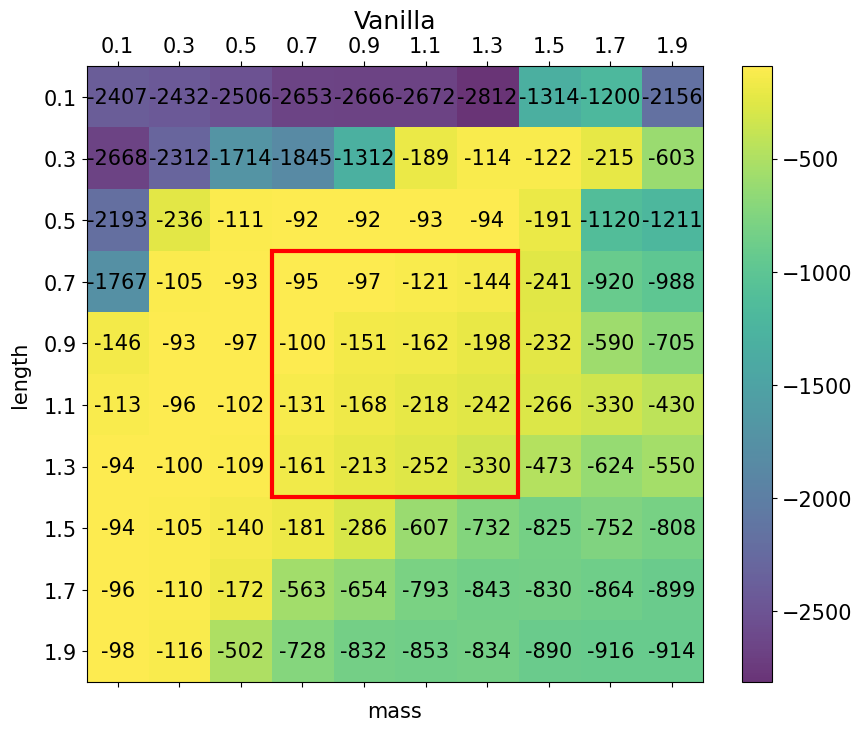

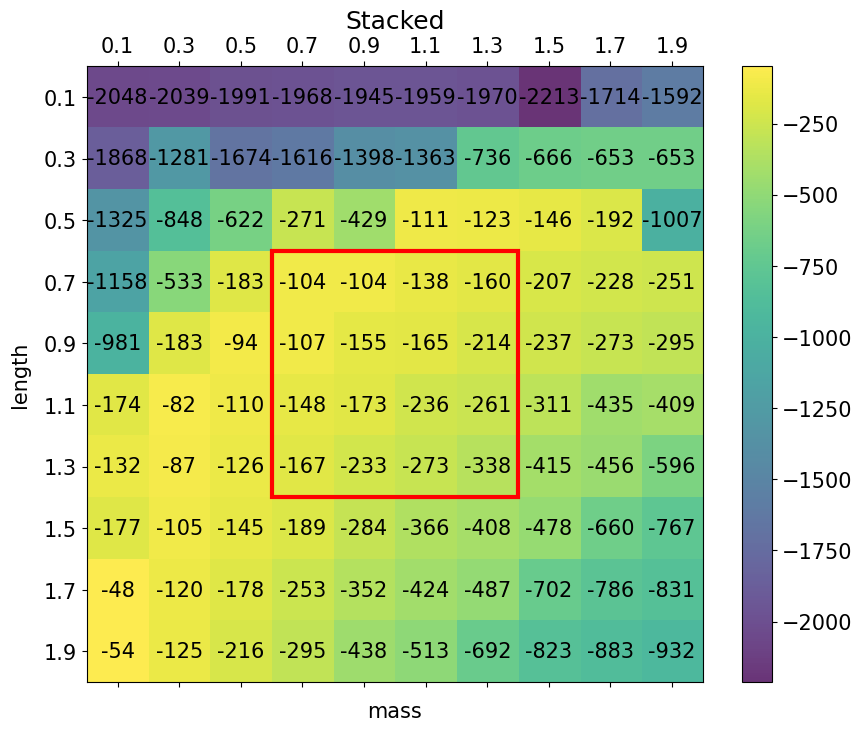

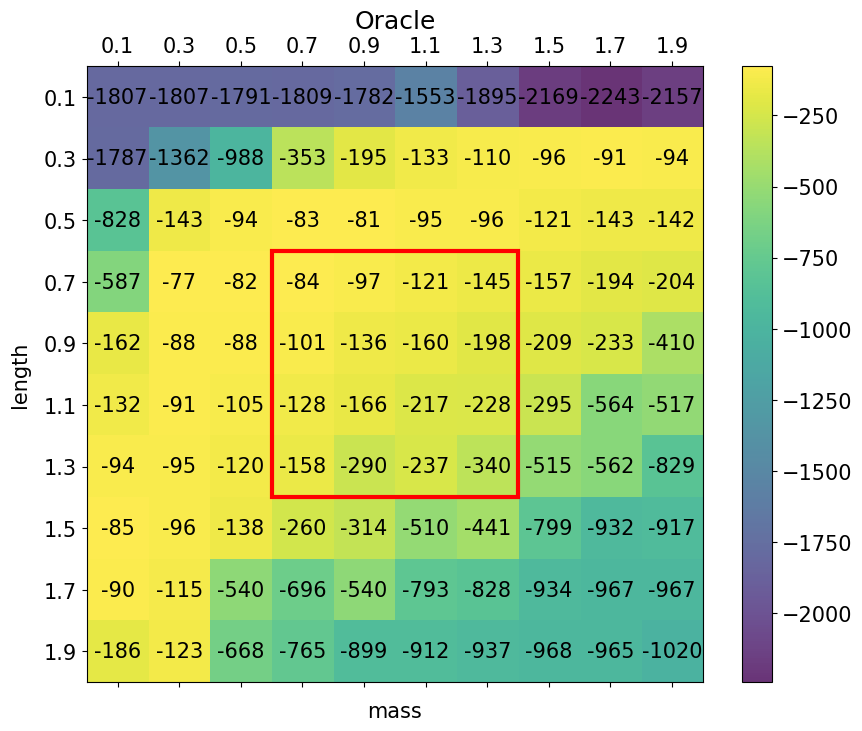

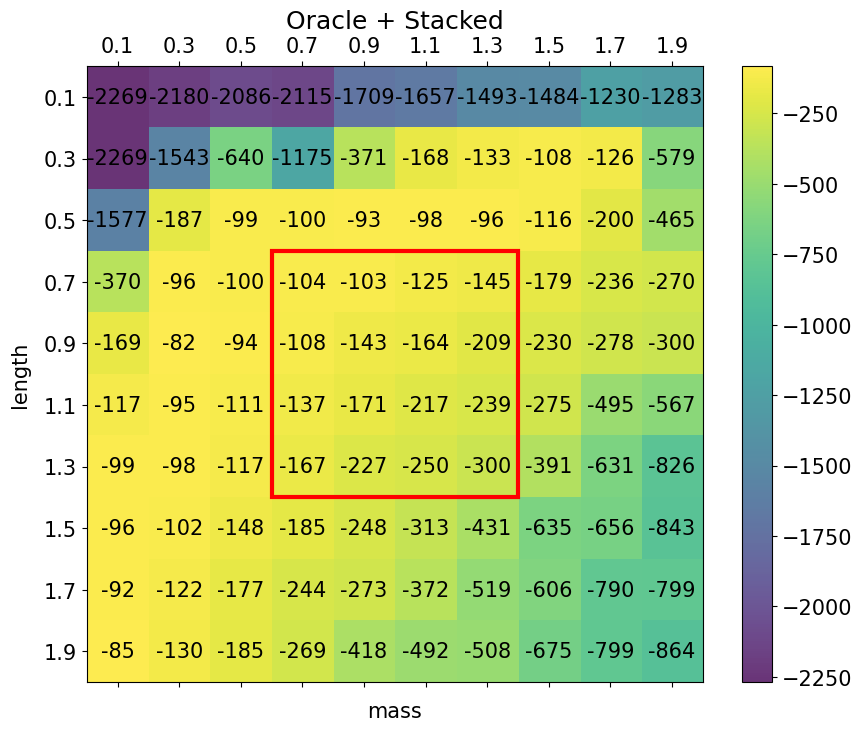

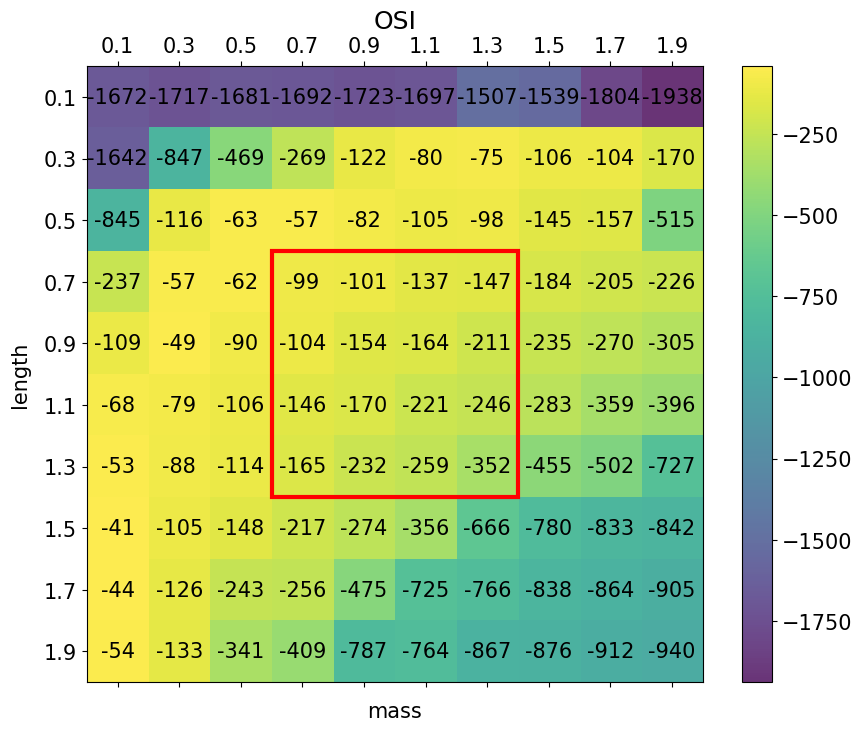

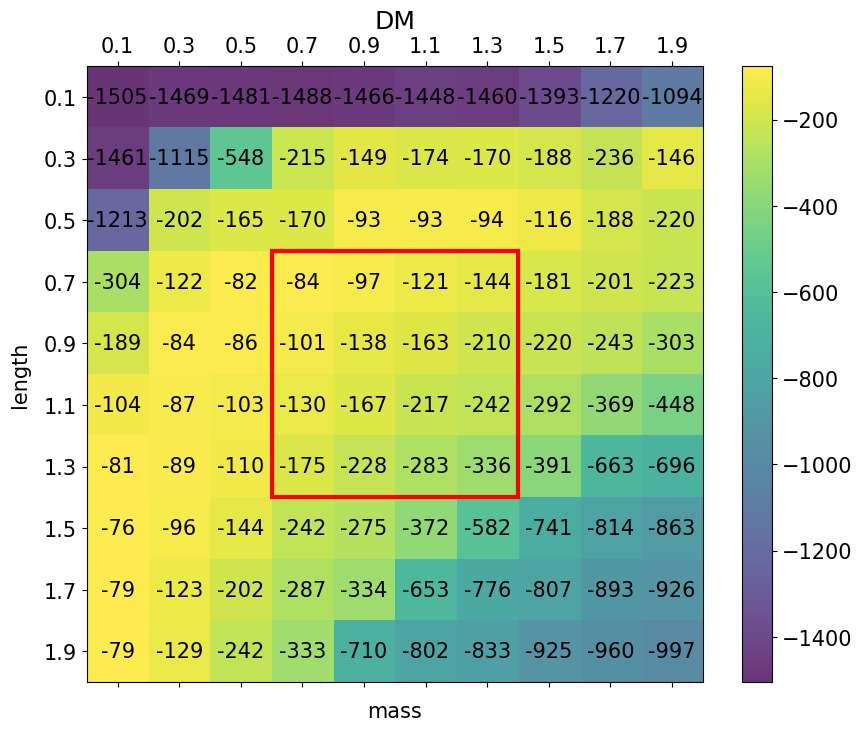

In [5]:
env_config_id = "train"

# checkpoint_idxs = defaultdict(list)
return_means = defaultdict(list)
return_stds = defaultdict(list)

for method in methods:
    for test_env_config_id in test_env_config_ids:
        checkpoint_directory = f"../runs/test/seed_{training_seed}/{env_id}/{test_env_config_id}/{env_config_id}/{method}"
        if not os.path.exists(checkpoint_directory):
            continue
        filenames = os.listdir(checkpoint_directory)
        for filename in filenames:
            if filename.startswith("event"):
                event_filename = filename
                break
        event_filename = os.path.join(checkpoint_directory, event_filename)

        event_acc = EventAccumulator(event_filename)
        event_acc.Reload()

        # print(event_acc.Tags())

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_mean"):
            # checkpoint_idxs[method].append(e.step)
            return_means[method].append(e.value)

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_std"):
            # checkpoint_idxs[method].append(e.step)
            return_stds[method].append(e.value)
    
for method in return_means:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Create the heatmap
    performance_data = np.array(return_means[method]).reshape((10, 10))
    cax = ax.matshow(performance_data, cmap='viridis', alpha=0.8)

    highlight = Rectangle((2.5, 2.5), 4, 4, color='red', fill=False, lw=3, linestyle='-')
    ax.add_patch(highlight)

    # Add color bar to show the scale
    plt.colorbar(cax)

    # Setting the tick marks
    ax.set_yticks(np.arange(len(c1_values)))
    ax.set_xticks(np.arange(len(c2_values)))
    # Set axis labels
    ax.set_yticklabels(list(c1_values))
    ax.set_xticklabels(list(c2_values))

    # Rotate the tick labels for the x-axis
    plt.xticks(rotation=0)

    # Set the title and axis labels
    ax.set_ylabel('length', labelpad=10)
    ax.set_xlabel('mass', labelpad=10)
    ax.set_title(f'{method_names[method]}')

    # Annotate each cell with the numeric value
    for i in range(len(c1_values)):
        for j in range(len(c2_values)):
            text = ax.text(j, i, int(performance_data[i, j]),
                        ha="center", va="center", color="black")

    os.makedirs(f"evaluation/{env_id}", exist_ok=True)
    plt.savefig(f"evaluation/{env_id}/{env_config_id}_{method}.pdf")
    plt.show()

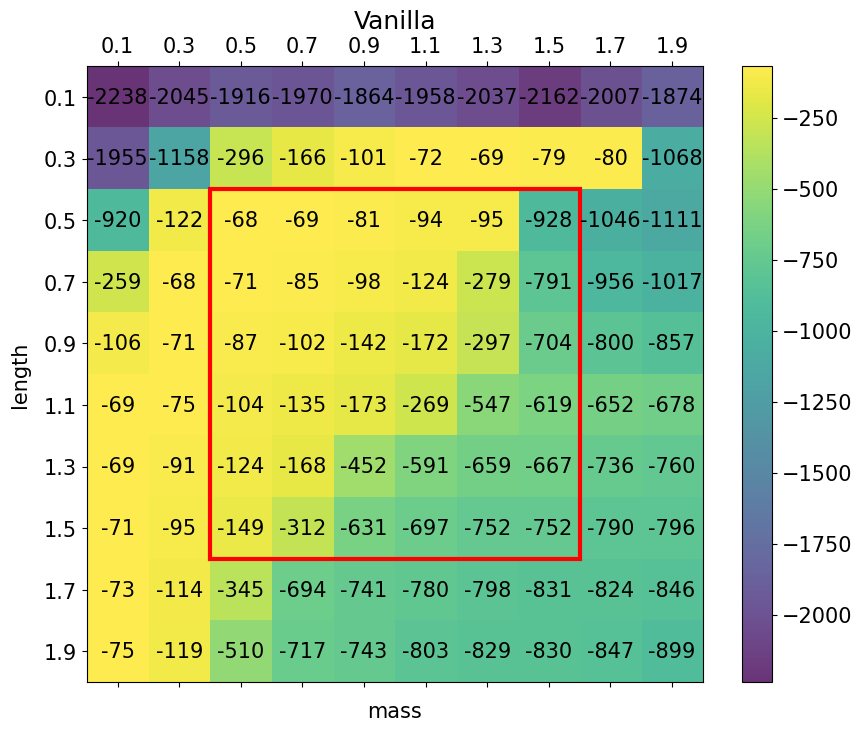

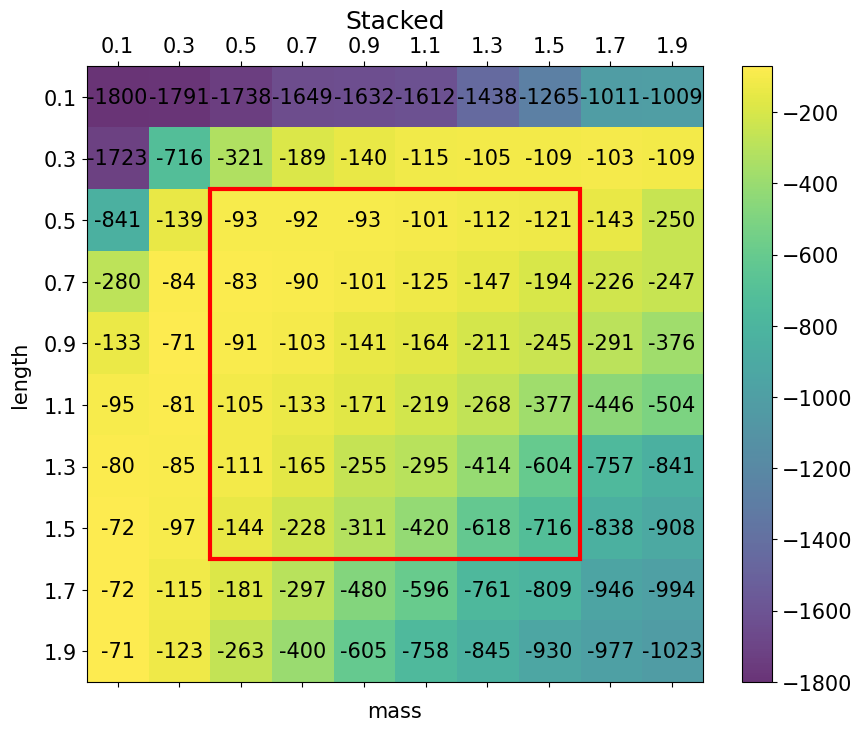

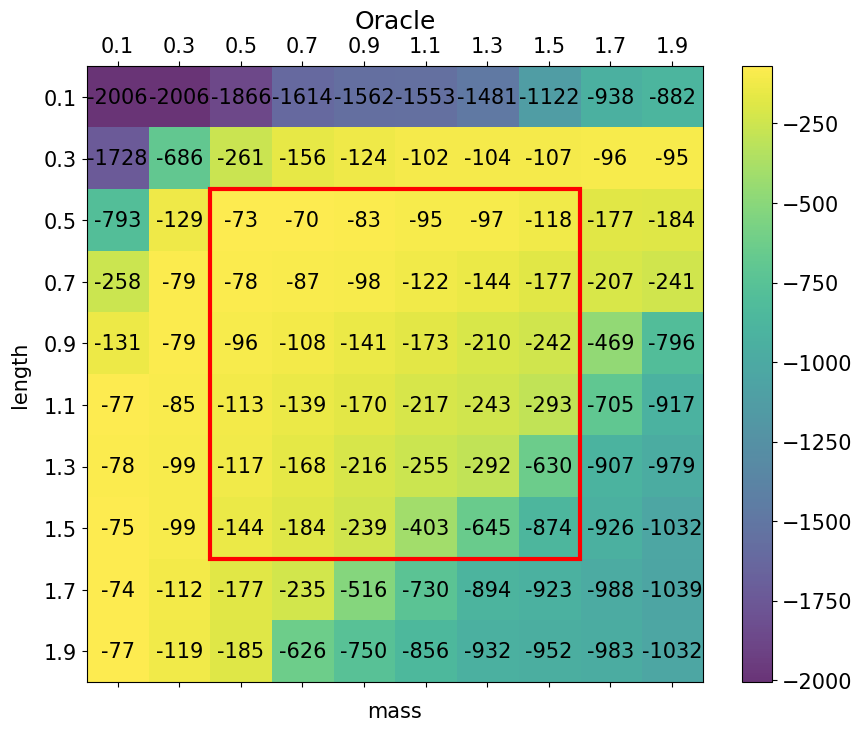

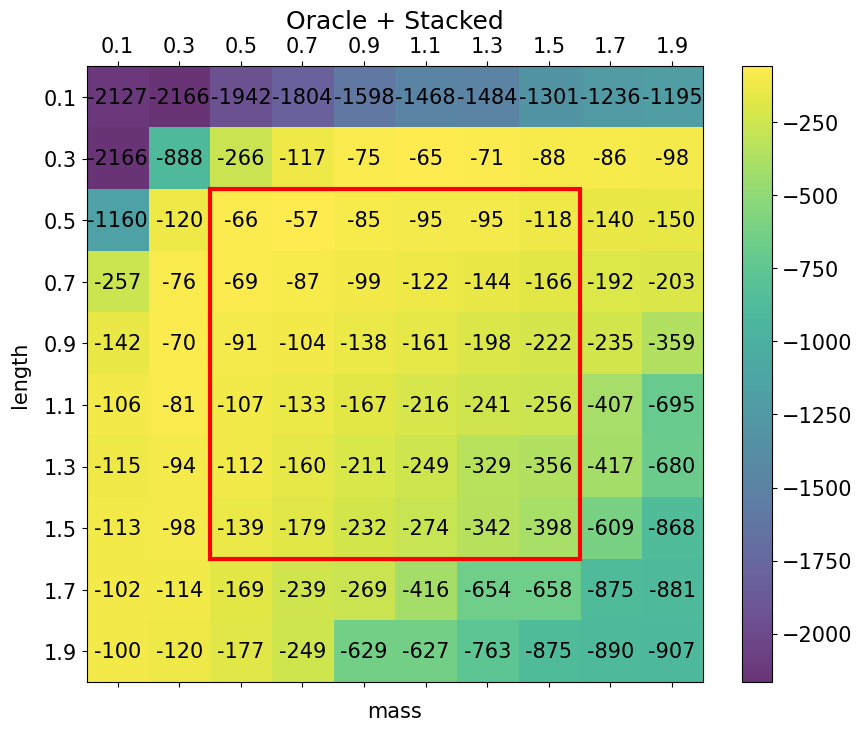

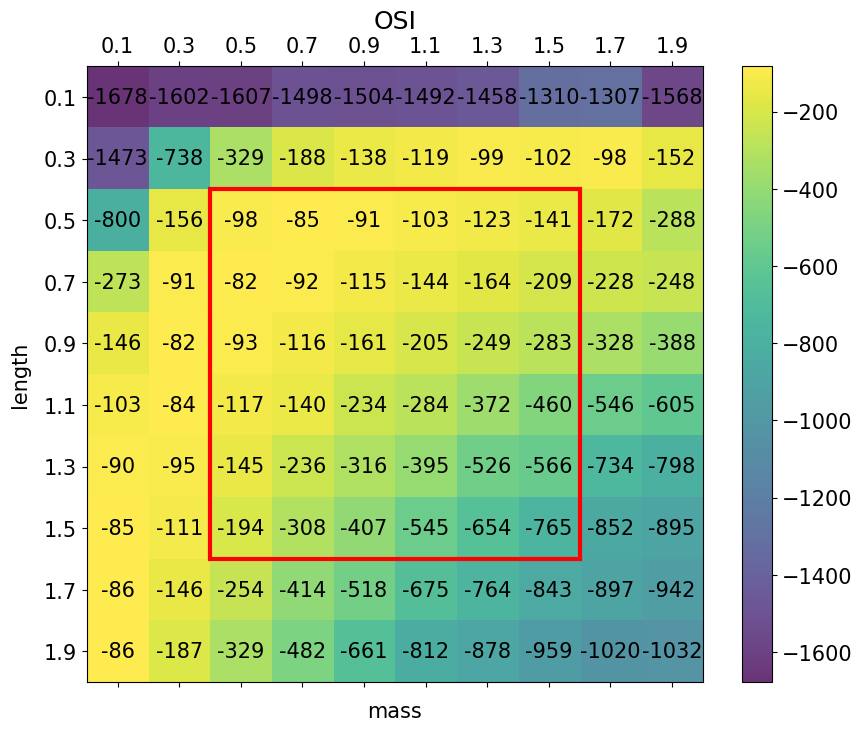

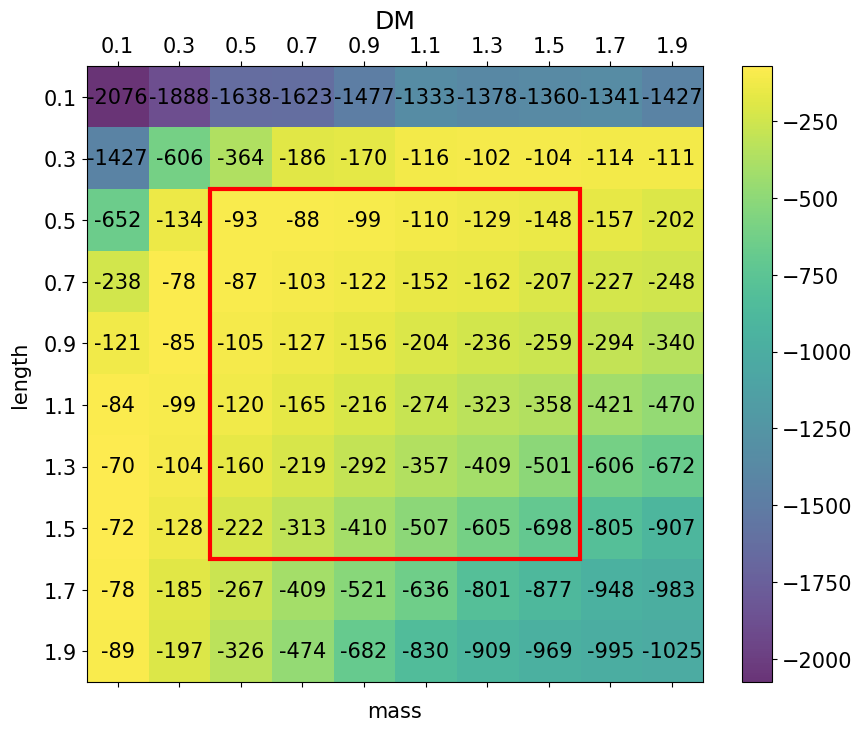

In [6]:
env_config_id = "train_wide"

# checkpoint_idxs = defaultdict(list)
return_means = defaultdict(list)
return_stds = defaultdict(list)

for method in methods:
    for test_env_config_id in test_env_config_ids:
        checkpoint_directory = f"../runs/test/seed_{training_seed}/{env_id}/{test_env_config_id}/{env_config_id}/{method}"
        if not os.path.exists(checkpoint_directory):
            continue
        filenames = os.listdir(checkpoint_directory)
        for filename in filenames:
            if filename.startswith("event"):
                event_filename = filename
                break
        event_filename = os.path.join(checkpoint_directory, event_filename)

        event_acc = EventAccumulator(event_filename)
        event_acc.Reload()

        # print(event_acc.Tags())

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_mean"):
            # checkpoint_idxs[method].append(e.step)
            return_means[method].append(e.value)

        for e in event_acc.Scalars(f"evaluation/seed_{test_seed}/episodic_return_std"):
            # checkpoint_idxs[method].append(e.step)
            return_stds[method].append(e.value)
    
for method in return_means:
    fig, ax = plt.subplots(figsize=(10, 8))

    # Create the heatmap
    performance_data = np.array(return_means[method]).reshape((10, 10))
    cax = ax.matshow(performance_data, cmap='viridis', alpha=0.8)

    highlight = Rectangle((1.5, 1.5), 6, 6, color='red', fill=False, lw=3, linestyle='-')
    ax.add_patch(highlight)

    # Add color bar to show the scale
    plt.colorbar(cax)

    # Setting the tick marks
    ax.set_yticks(np.arange(len(c1_values)))
    ax.set_xticks(np.arange(len(c2_values)))
    # Set axis labels
    ax.set_yticklabels(list(c1_values))
    ax.set_xticklabels(list(c2_values))

    # Rotate the tick labels for the x-axis
    plt.xticks(rotation=0)

    # Set the title and axis labels
    ax.set_ylabel('length', labelpad=10)
    ax.set_xlabel('mass', labelpad=10)
    ax.set_title(f'{method_names[method]}')

    # Annotate each cell with the numeric value
    for i in range(len(c1_values)):
        for j in range(len(c2_values)):
            text = ax.text(j, i, int(performance_data[i, j]),
                        ha="center", va="center", color="black")

    os.makedirs(f"evaluation/{env_id}", exist_ok=True)
    plt.savefig(f"evaluation/{env_id}/{env_config_id}_{method}.pdf")
    plt.show()